# Morfološke operacije na multispektralnih indeksih

Implementacija morfoloških operacij brez uporabe zunanjih knjižnic.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time
import os
from pathlib import Path


## 1. Nalaganje podatkov


In [ ]:
def load_band(band_name, resolution):
    path = Path(f'data/IMG_DATA/R{resolution}m/{band_name}_{resolution}m.jp2')
    try:
        import glymur
        jp2 = glymur.Jp2k(str(path))
        return jp2[:].astype(np.float32)
    except (ImportError, SyntaxError):
        img = Image.open(str(path))
        return np.array(img).astype(np.float32)

b02 = load_band('T34TGK_20251228T092319_B02', 10)  # Blue
b03 = load_band('T34TGK_20251228T092319_B03', 10)  # Green
b04 = load_band('T34TGK_20251228T092319_B04', 10)  # Red
b08 = load_band('T34TGK_20251228T092319_B08', 10)  # NIR

print(f"Dimenzije slik: {b02.shape}")
print(f"Tip podatkov: {b02.dtype}")


/Users/stefansrjakovferi/Library/Python/3.9/lib/python/site-packages/PIL/Image.py:3442: DecompressionBombWarning: Image size (120560400 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Dimenzije slik: (10980, 10980)
Tip podatkov: float32


## 2. Izračun multispektralnih indeksov


In [ ]:
def normalize_to_uint8(img):
    img_min = np.nanmin(img)
    img_max = np.nanmax(img)
    if img_max == img_min:
        return np.zeros_like(img, dtype=np.uint8)
    normalized = (img - img_min) / (img_max - img_min) * 255
    return normalized.astype(np.uint8)

# NDVI
def calculate_ndvi(nir, red):
    nir = nir.astype(np.float32)
    red = red.astype(np.float32)
    ndvi = (nir - red) / (nir + red + 1e-10)
    return normalize_to_uint8(ndvi)

# NDWI
def calculate_ndwi(green, nir):
    green = green.astype(np.float32)
    nir = nir.astype(np.float32)
    ndwi = (green - nir) / (green + nir + 1e-10)
    return normalize_to_uint8(ndwi)

# NDBI
def calculate_ndbi(red, nir):
    red = red.astype(np.float32)
    nir = nir.astype(np.float32)
    ndbi = (red - nir) / (red + nir + 1e-10)
    return normalize_to_uint8(ndbi)

ndvi = calculate_ndvi(b08, b04)
ndwi = calculate_ndwi(b03, b08)
ndbi = calculate_ndbi(b04, b08)

## 3. Osnovne morfološke operacije


In [25]:
def erozija(img, filter_size=3):
    h, w = img.shape
    pad = filter_size // 2
    result = np.zeros_like(img)
    
    padded = np.pad(img, pad, mode='edge')
    
    for y in range(h):
        for x in range(w):
            window = padded[y:y+filter_size, x:x+filter_size]
            result[y, x] = np.min(window)
    
    return result

def dilatacija(img, filter_size=3):
    h, w = img.shape
    pad = filter_size // 2
    result = np.zeros_like(img)
    
    padded = np.pad(img, pad, mode='edge')
    
    for y in range(h):
        for x in range(w):
            window = padded[y:y+filter_size, x:x+filter_size]
            result[y, x] = np.max(window)
    
    return result

## 4. Morfološko odpiranje in zapiranje


In [26]:
def odpiranje(img, filter_size=3):
    eroded = erozija(img, filter_size)
    opened = dilatacija(eroded, filter_size)
    return opened

def zapiranje(img, filter_size=3):
    dilated = dilatacija(img, filter_size)
    closed = erozija(dilated, filter_size)
    return closed


## 5. Odpiranje z rekonstrukcijo


In [27]:
def odpiranje_z_rekonstrukcijo(img, marker_size=5, max_iter=1000):
    start_time = time.time()
    
    # 1. Krčenje za označevalno sliko
    marker = erozija(img, marker_size)
    
    # 2. Iterativno širjenje z rekonstrukcijo
    iterations = 0
    while iterations < max_iter:
        prev_marker = marker.copy()
        
        dilated = dilatacija(marker, 3)
        
        marker = np.minimum(dilated, img)
        
        iterations += 1
        
        if np.array_equal(marker, prev_marker):
            break
    
    elapsed_time = time.time() - start_time
    
    return marker, iterations, elapsed_time



## 6. Zapiranje z rekonstrukcijo


In [28]:
def zapiranje_z_rekonstrukcijo(img, marker_size=5, max_iter=1000):
    start_time = time.time()
    
    # 1. Širjenje za označevalno sliko
    marker = dilatacija(img, marker_size)
    
    # 2. Iterativno krčenje z rekonstrukcijo
    iterations = 0
    while iterations < max_iter:
        prev_marker = marker.copy()
        
        eroded = erozija(marker, 3)
        
        marker = np.maximum(eroded, img)
        
        iterations += 1
        
        if np.array_equal(marker, prev_marker):
            break
    
    elapsed_time = time.time() - start_time
    
    return marker, iterations, elapsed_time



## 7. Izbira področij za analizo


In [29]:
# Področje 1: zgornji levi kot
region1 = (slice(0, 500), slice(0, 500))

# Področje 2: sredina
h, w = ndvi.shape
region2 = (slice(h//2-250, h//2+250), slice(w//2-250, w//2+250))

# Področje 3: leva stran (vertikalno na sredini)
region3 = (slice(h//2-250, h//2+250), slice(0, 500))

regions = [region1, region2, region3]
region_names = ['Področje 1: Zgornji levi kot', 'Področje 2: Sredina', 'Področje 3: Leva sredina']


## 8. Procesiranje in vizualizacija


In [30]:
def process_and_display(img, region, region_name, index_name, filter_size=5):
    roi = img[region].copy()
    
    print(f"\n{'='*60}")
    print(f"{region_name} - {index_name}")
    print(f"{'='*60}")
    
    opened = odpiranje(roi, filter_size)
    closed = zapiranje(roi, filter_size)
    
    opened_rec, iter_open, time_open = odpiranje_z_rekonstrukcijo(roi, filter_size)
    print(f"Odpiranje z rekonstrukcijo: {iter_open} iteracij, {time_open:.3f}s")
    
    closed_rec, iter_close, time_close = zapiranje_z_rekonstrukcijo(roi, filter_size)
    print(f"Zapiranje z rekonstrukcijo: {iter_close} iteracij, {time_close:.3f}s")
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'{region_name} - {index_name}', fontsize=16)
    
    axes[0, 0].imshow(roi, cmap='gray')
    axes[0, 0].set_title('Originalna slika')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(opened, cmap='gray')
    axes[0, 1].set_title(f'Odpiranje (S={filter_size})')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(closed, cmap='gray')
    axes[0, 2].set_title(f'Zapiranje (S={filter_size})')
    axes[0, 2].axis('off')
    
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(opened_rec, cmap='gray')
    axes[1, 1].set_title(f'Odpiranje z rekonstrukcijo\\nIteracije: {iter_open}, Čas: {time_open:.3f}s')
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(closed_rec, cmap='gray')
    axes[1, 2].set_title(f'Zapiranje z rekonstrukcijo\\nIteracije: {iter_close}, Čas: {time_close:.3f}s')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'iter_open': iter_open,
        'time_open': time_open,
        'iter_close': iter_close,
        'time_close': time_close
    }


## 9. Področje 1 - NDVI



Področje 1: Zgornji levi kot - NDVI
Odpiranje z rekonstrukcijo: 85 iteracij, 67.336s
Zapiranje z rekonstrukcijo: 121 iteracij, 101.356s


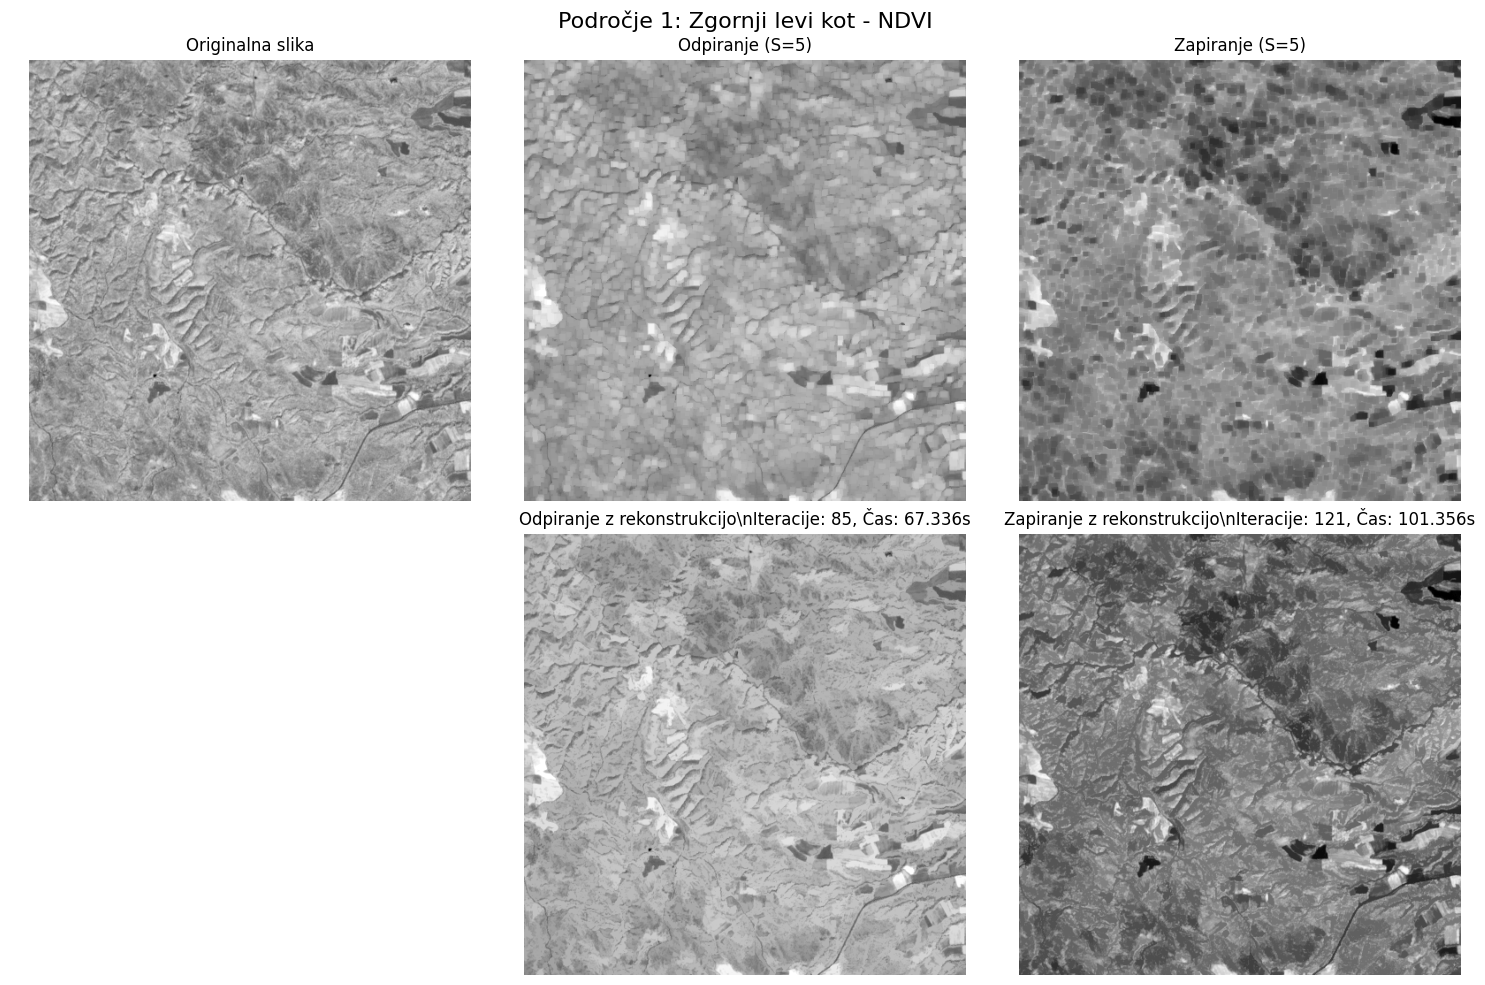

In [13]:
results_p1 = process_and_display(ndvi, regions[0], region_names[0], 'NDVI', filter_size=5)


## 10. Področje 2 - NDWI



Področje 2: Sredina - NDWI
Odpiranje z rekonstrukcijo: 226 iteracij, 206.073s
Zapiranje z rekonstrukcijo: 410 iteracij, 336.352s


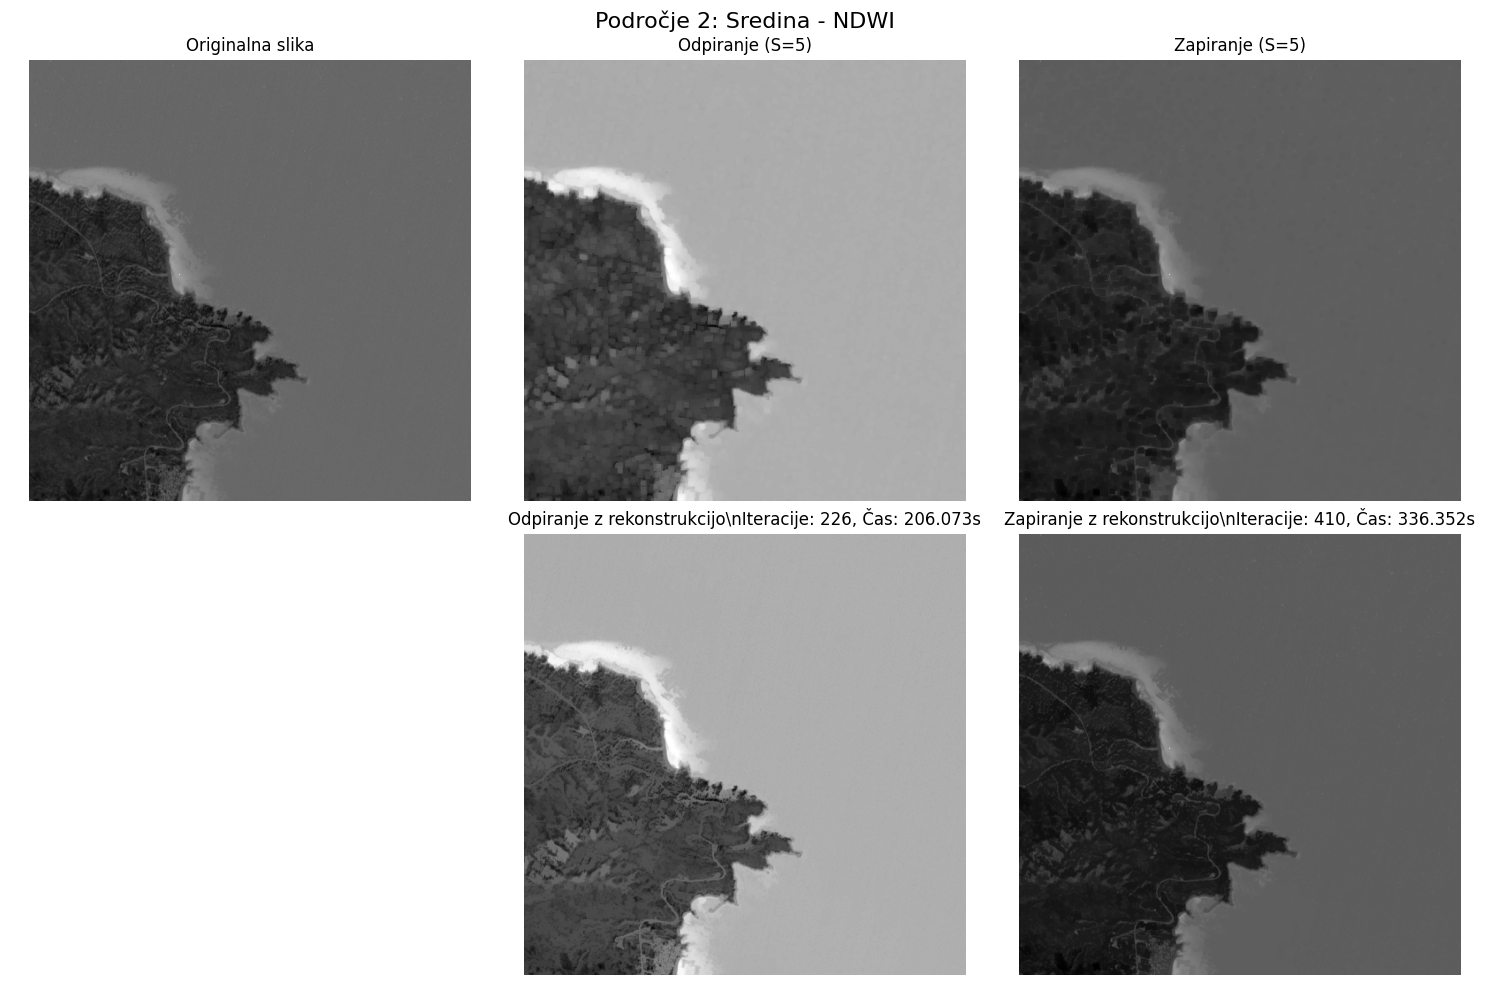

In [14]:
results_p2 = process_and_display(ndwi, regions[1], region_names[1], 'NDWI', filter_size=5)



Področje 3: Leva sredina - NDBI
Odpiranje z rekonstrukcijo: 176 iteracij, 142.690s
Zapiranje z rekonstrukcijo: 172 iteracij, 140.609s


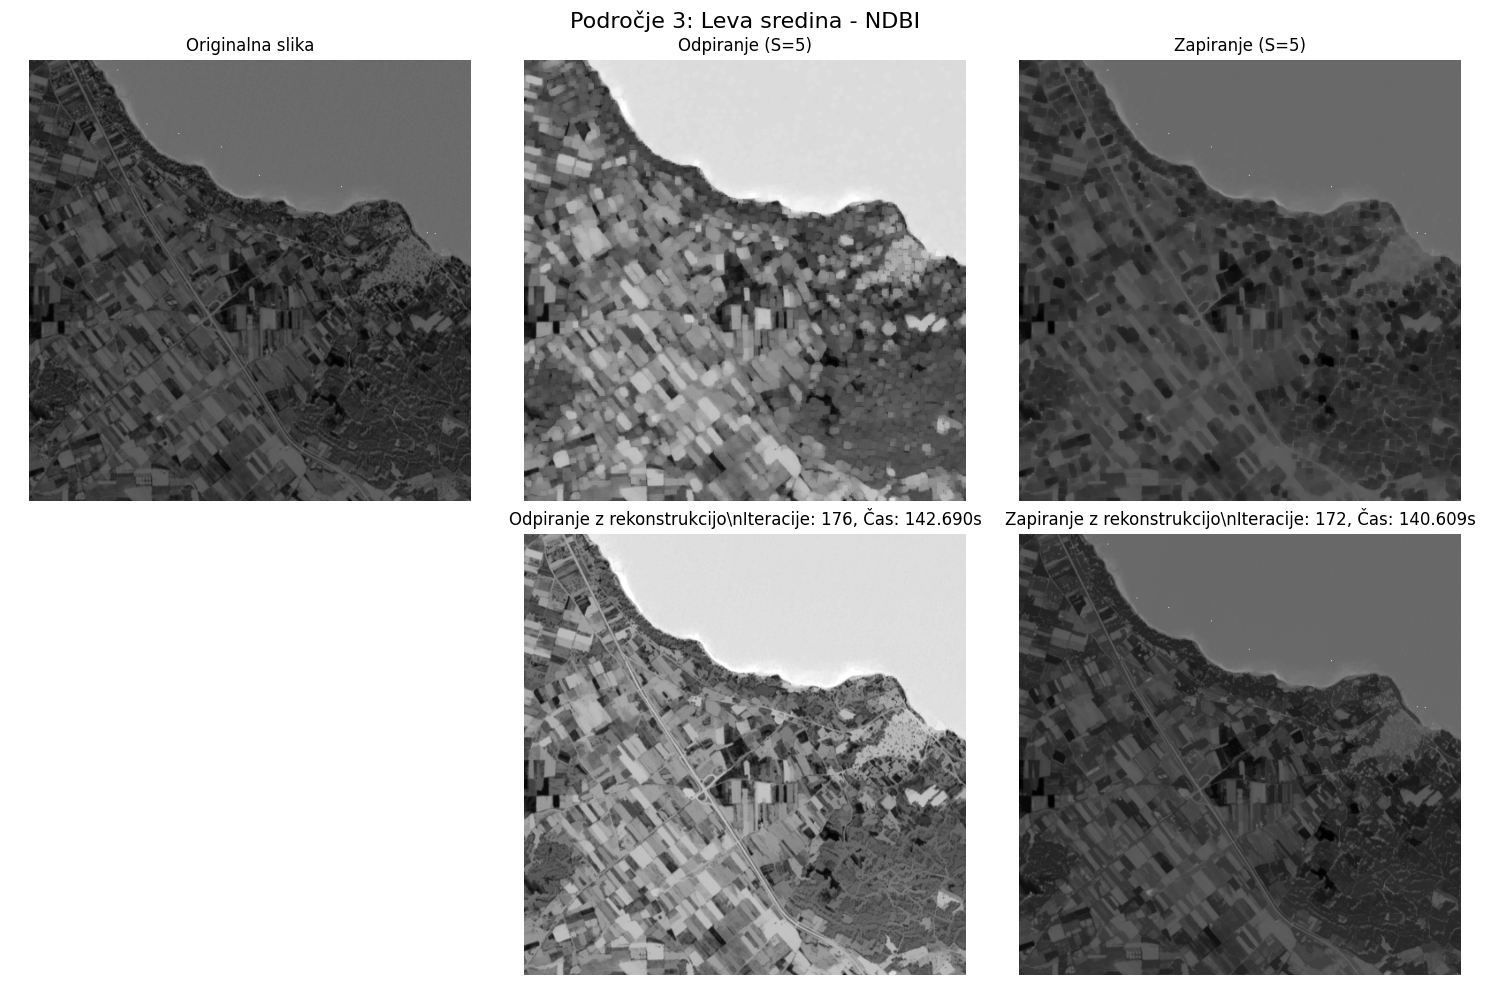

In [18]:
results_p3 = process_and_display(ndbi, regions[2], region_names[2], 'NDBI', filter_size=5)


## 12. BONUS: Različne oblike filtrov


In [31]:
def erozija_custom(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2
    result = np.zeros_like(img)
    
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    
    for y in range(h):
        for x in range(w):
            window = padded[y:y+kh, x:x+kw]
            values = window[kernel]
            result[y, x] = np.min(values)
    
    return result

def dilatacija_custom(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2
    result = np.zeros_like(img)
    
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    
    for y in range(h):
        for x in range(w):
            window = padded[y:y+kh, x:x+kw]
            values = window[kernel]
            result[y, x] = np.max(values)
    
    return result

def odpiranje_z_rekonstrukcijo_custom(img, marker_kernel, recon_kernel, max_iter=1000):
    start_time = time.time()
    
    marker = erozija_custom(img, marker_kernel)
    
    iterations = 0
    while iterations < max_iter:
        prev_marker = marker.copy()
        dilated = dilatacija_custom(marker, recon_kernel)
        marker = np.minimum(dilated, img)
        iterations += 1
        
        if np.array_equal(marker, prev_marker):
            break
    
    elapsed_time = time.time() - start_time
    return marker, iterations, elapsed_time

def zapiranje_z_rekonstrukcijo_custom(img, marker_kernel, recon_kernel, max_iter=1000):
    start_time = time.time()
    
    marker = dilatacija_custom(img, marker_kernel)
    
    iterations = 0
    while iterations < max_iter:
        prev_marker = marker.copy()
        eroded = erozija_custom(marker, recon_kernel)
        marker = np.maximum(eroded, img)
        iterations += 1
        
        if np.array_equal(marker, prev_marker):
            break
    
    elapsed_time = time.time() - start_time
    return marker, iterations, elapsed_time


In [ ]:
# Definicija različnih oblik filtrov

# 1. Kvadratni filter (privzeti)
square_5x5 = np.ones((5, 5), dtype=bool)
square_3x3 = np.ones((3, 3), dtype=bool)

# 2. Križni filter
cross_5x5 = np.array([
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [1, 1, 1, 1, 1],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0]
], dtype=bool)

cross_3x3 = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
], dtype=bool)

# 3. Diamantni filter
diamond_5x5 = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [1, 1, 1, 1, 1],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0]
], dtype=bool)

diamond_3x3 = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
], dtype=bool)

print(f"Kvadratni 5x5:\n{square_5x5.astype(int)}")
print(f"\nKrižni 5x5:\n{cross_5x5.astype(int)}")
print(f"\nDiamantni 5x5:\n{diamond_5x5.astype(int)}")


Kerneli definirani
Kvadratni 5x5:
[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]

Križni 5x5:
[[0 0 1 0 0]
 [0 0 1 0 0]
 [1 1 1 1 1]
 [0 0 1 0 0]
 [0 0 1 0 0]]

Diamantni 5x5:
[[0 0 1 0 0]
 [0 1 1 1 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 0]]


## 13. Primerjava različnih filtrov


In [ ]:
test_img = ndvi[regions[0]].copy()

print("Primerjava različnih oblik filtrov na istem področju (NDVI - Področje 1)\n")
print("="*80)

# Kvadratni filter
print("\n1. KVADRATNI FILTER")
open_sq, iter_o_sq, time_o_sq = odpiranje_z_rekonstrukcijo_custom(test_img, square_5x5, square_3x3)
close_sq, iter_c_sq, time_c_sq = zapiranje_z_rekonstrukcijo_custom(test_img, square_5x5, square_3x3)
print(f"   Odpiranje: {iter_o_sq} iteracij, {time_o_sq:.3f}s")
print(f"   Zapiranje: {iter_c_sq} iteracij, {time_c_sq:.3f}s")

# Križni filter
print("\n2. KRIŽNI FILTER")
open_cr, iter_o_cr, time_o_cr = odpiranje_z_rekonstrukcijo_custom(test_img, cross_5x5, cross_3x3)
close_cr, iter_c_cr, time_c_cr = zapiranje_z_rekonstrukcijo_custom(test_img, cross_5x5, cross_3x3)
print(f"   Odpiranje: {iter_o_cr} iteracij, {time_o_cr:.3f}s")
print(f"   Zapiranje: {iter_c_cr} iteracij, {time_c_cr:.3f}s")

# Diamantni filter
print("\n3. DIAMANTNI FILTER")
open_di, iter_o_di, time_o_di = odpiranje_z_rekonstrukcijo_custom(test_img, diamond_5x5, diamond_3x3)
close_di, iter_c_di, time_c_di = zapiranje_z_rekonstrukcijo_custom(test_img, diamond_5x5, diamond_3x3)
print(f"   Odpiranje: {iter_o_di} iteracij, {time_o_di:.3f}s")
print(f"   Zapiranje: {iter_c_di} iteracij, {time_c_di:.3f}s")

print("\n" + "="*80)


Primerjava različnih oblik filtrov na istem področju (NDVI - Področje 1)


1. KVADRATNI FILTER
   Odpiranje: 85 iteracij, 72.172s
   Zapiranje: 121 iteracij, 98.846s

2. KRIŽNI FILTER
   Odpiranje: 54 iteracij, 45.486s
   Zapiranje: 134 iteracij, 118.826s

3. DIAMANTNI FILTER
   Odpiranje: 58 iteracij, 51.284s
   Zapiranje: 134 iteracij, 115.091s



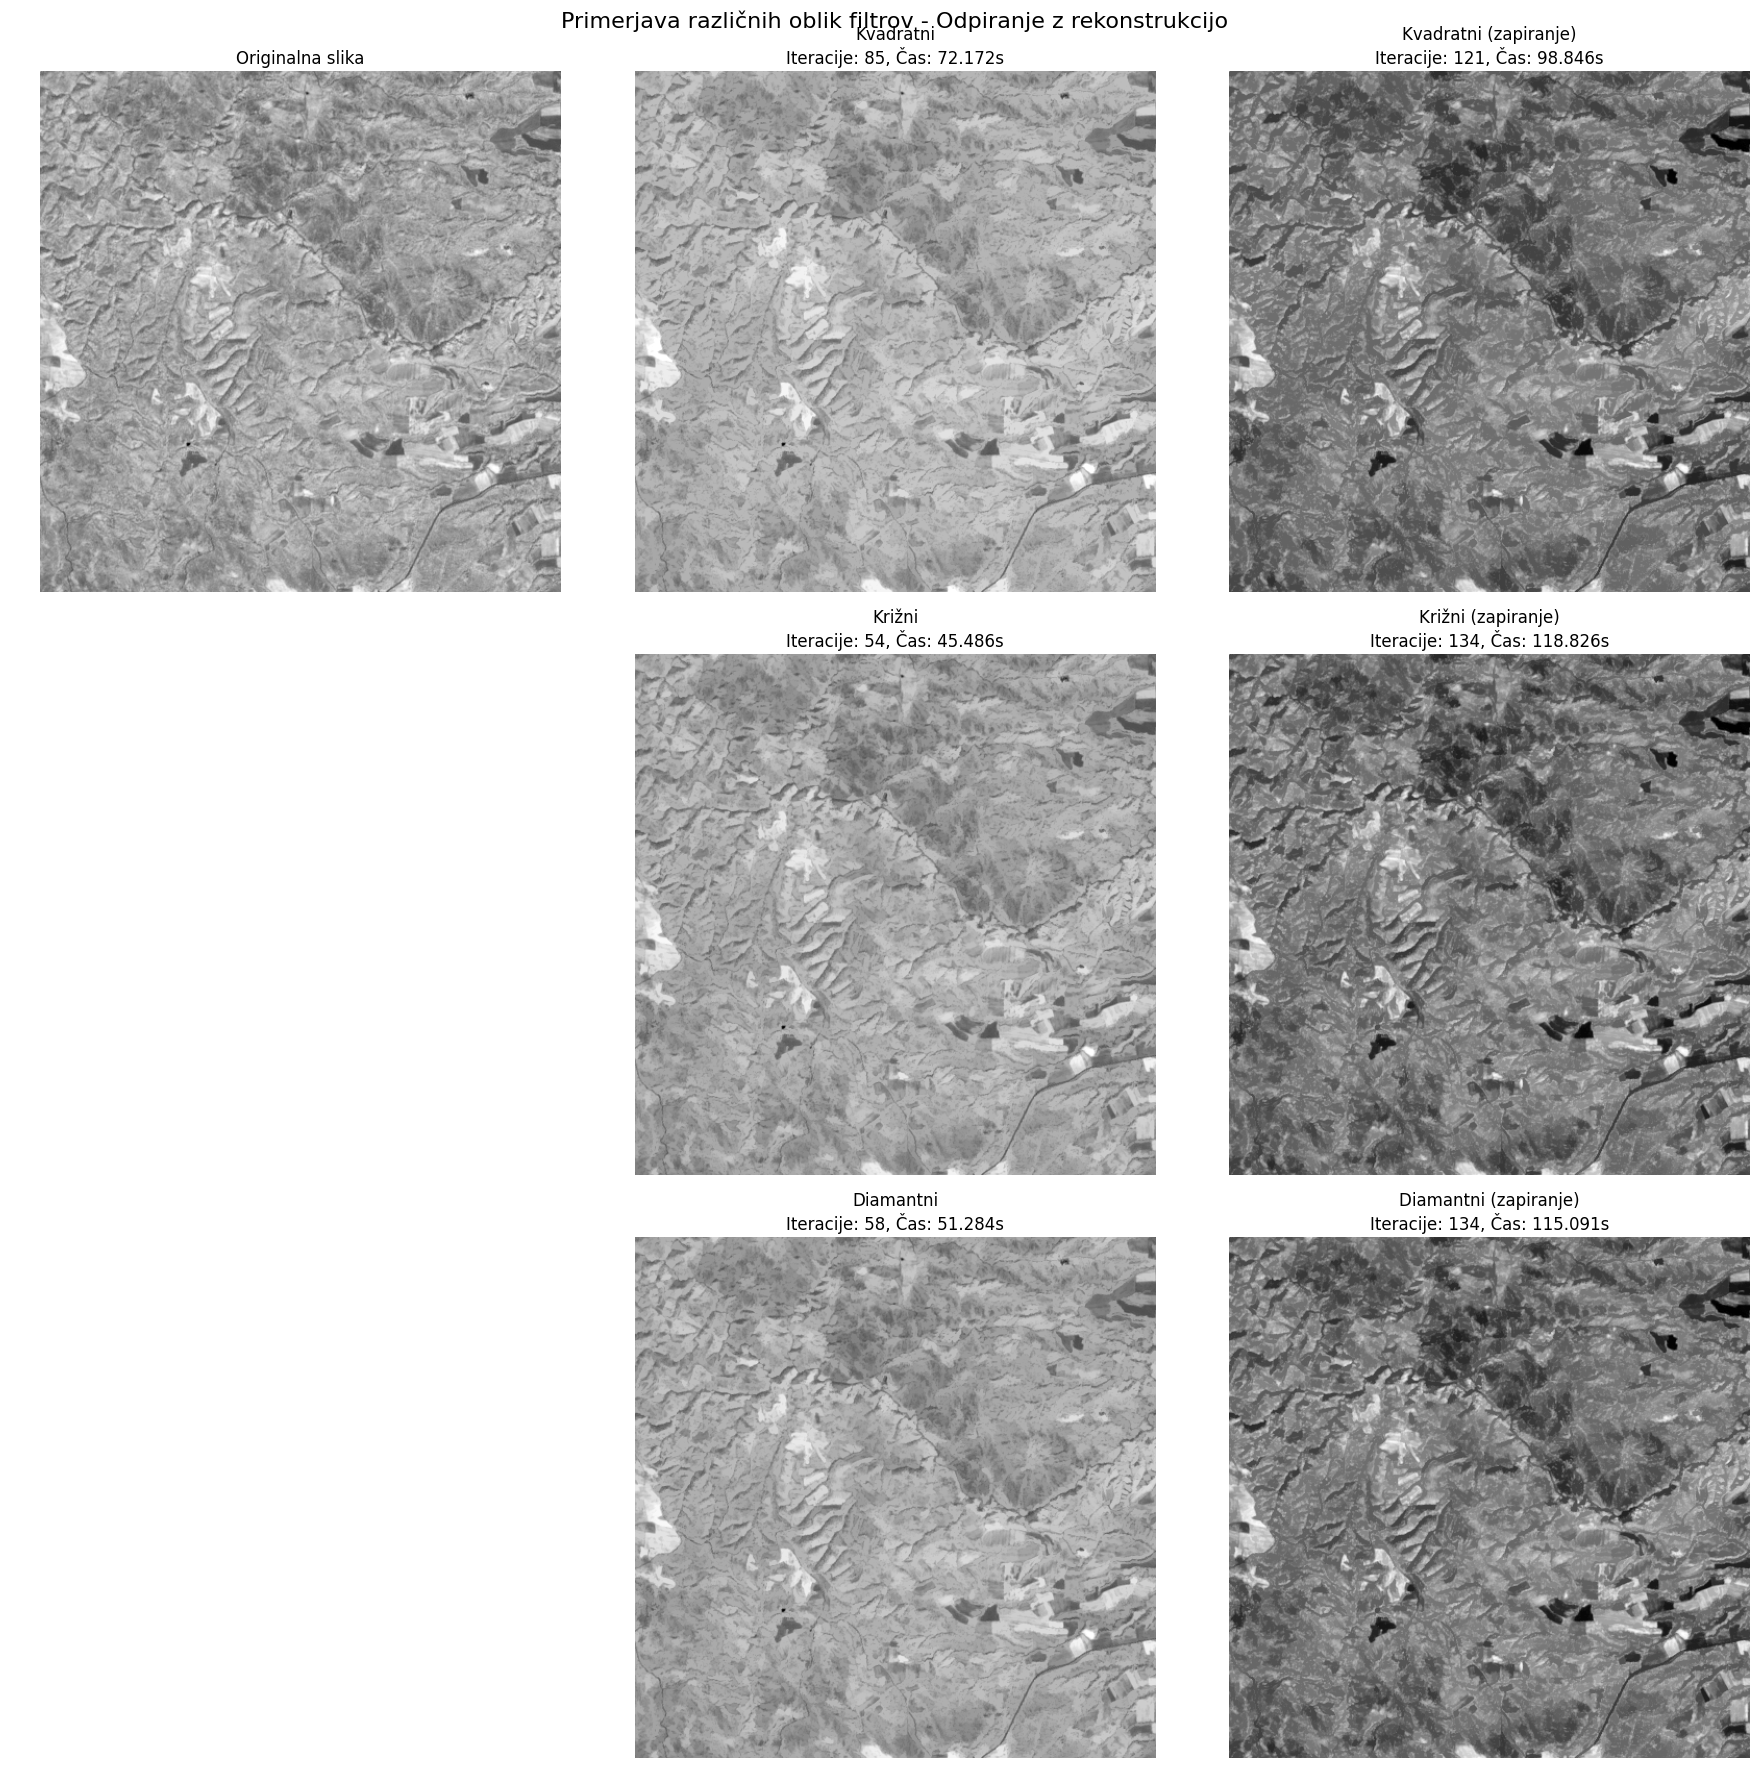

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.suptitle('Primerjava različnih oblik filtrov - Odpiranje z rekonstrukcijo', fontsize=16)

# Originalna slika v prvi vrstici
axes[0, 0].imshow(test_img, cmap='gray')
axes[0, 0].set_title('Originalna slika')
axes[0, 0].axis('off')

# Kvadratni filter
axes[0, 1].imshow(open_sq, cmap='gray')
axes[0, 1].set_title(f'Kvadratni\nIteracije: {iter_o_sq}, Čas: {time_o_sq:.3f}s')
axes[0, 1].axis('off')

axes[0, 2].imshow(close_sq, cmap='gray')
axes[0, 2].set_title(f'Kvadratni (zapiranje)\nIteracije: {iter_c_sq}, Čas: {time_c_sq:.3f}s')
axes[0, 2].axis('off')

# Križni filter
axes[1, 0].axis('off')

axes[1, 1].imshow(open_cr, cmap='gray')
axes[1, 1].set_title(f'Križni\nIteracije: {iter_o_cr}, Čas: {time_o_cr:.3f}s')
axes[1, 1].axis('off')

axes[1, 2].imshow(close_cr, cmap='gray')
axes[1, 2].set_title(f'Križni (zapiranje)\nIteracije: {iter_c_cr}, Čas: {time_c_cr:.3f}s')
axes[1, 2].axis('off')

# Diamantni filter
axes[2, 0].axis('off')

axes[2, 1].imshow(open_di, cmap='gray')
axes[2, 1].set_title(f'Diamantni\nIteracije: {iter_o_di}, Čas: {time_o_di:.3f}s')
axes[2, 1].axis('off')

axes[2, 2].imshow(close_di, cmap='gray')
axes[2, 2].set_title(f'Diamantni (zapiranje)\nIteracije: {iter_c_di}, Čas: {time_c_di:.3f}s')
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()


## 14. Primerjalna tabela


In [ ]:
import pandas as pd

comparison_data = {
    'Oblika filtra': ['Kvadratni', 'Križni', 'Diamantni'],
    'Odpiranje - Iteracije': [iter_o_sq, iter_o_cr, iter_o_di],
    'Odpiranje - Čas (s)': [f'{time_o_sq:.3f}', f'{time_o_cr:.3f}', f'{time_o_di:.3f}'],
    'Zapiranje - Iteracije': [iter_c_sq, iter_c_cr, iter_c_di],
    'Zapiranje - Čas (s)': [f'{time_c_sq:.3f}', f'{time_c_cr:.3f}', f'{time_c_di:.3f}']
}

df_comparison = pd.DataFrame(comparison_data)
print("\nPrimerjava različnih oblik filtrov:")
print(df_comparison.to_string(index=False))



Primerjava različnih oblik filtrov:
Oblika filtra  Odpiranje - Iteracije Odpiranje - Čas (s)  Zapiranje - Iteracije Zapiranje - Čas (s)
    Kvadratni                     85              72.172                    121              98.846
       Križni                     54              45.486                    134             118.826
    Diamantni                     58              51.284                    134             115.091
